In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

### 1 - Acquisition des tags

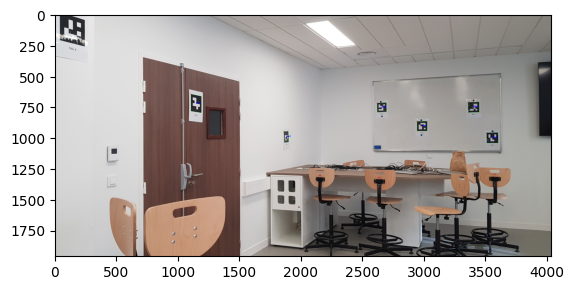

In [11]:
img = cv2.imread('Image_tags.jpg')

# Détection de codes ArUco
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_parameters = cv2.aruco.DetectorParameters()
aruco_detector = cv2.aruco.ArucoDetector(dictionary=aruco_dict, detectorParams=aruco_parameters)
corners, ids, rejectedPoints = aruco_detector.detectMarkers(img)
I_aruco = cv2.aruco.drawDetectedMarkers(img, corners, ids)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR));

In [12]:

# print(corners)
# print(ids)
coord_world_tags = [[[3730,0,1810],[3567,0,1810],[3567,0,1647],[3730,0,1647]],
                    [[0,2740,1460],[0,2903,1460],[0,2903,1297],[0,2740,1297]],
                    [[0,2480,1940],[0,2643,1940],[0,2643,1777],[0,2480,1777]],
                    [[0,1700,1660],[0,1863,1660],[0,1863,1497],[0,1700,1497]],
                    [[0,1040,1990],[0,1203,1990],[0,1203,1827],[0,1040,1827]],
                    [[1640,0,1500],[1477,0,1500],[1477,0,1337],[1640,0,1337]]]
dict_tags = {'ind_tags':ids, 'coord_world_tags':coord_world_tags, 'coord_pixels_tags':corners}

### 2 - Calibrage de la caméra

In [18]:
i1 = img.shape[1]/2 # Largeur de l'image en pixel
i2 = img.shape[0]/2 # Hauteur de l'image en pixel

U1 = []
A = []
for i in range(len(ids)):
    for j in range(4):
        line = []
        line.append((dict_tags['coord_pixels_tags'][i][0][j][1]-i2)*dict_tags['coord_world_tags'][i][j][0])
        line.append((dict_tags['coord_pixels_tags'][i][0][j][1]-i2)*dict_tags['coord_world_tags'][i][j][1])
        line.append((dict_tags['coord_pixels_tags'][i][0][j][1]-i2)*dict_tags['coord_world_tags'][i][j][2])
        line.append(dict_tags['coord_pixels_tags'][i][0][j][1]-i2)
        line.append(-(dict_tags['coord_pixels_tags'][i][0][j][0]-i1)*dict_tags['coord_world_tags'][i][j][0])
        line.append(-(dict_tags['coord_pixels_tags'][i][0][j][0]-i1)*dict_tags['coord_world_tags'][i][j][1])
        line.append(-(dict_tags['coord_pixels_tags'][i][0][j][0]-i1)*dict_tags['coord_world_tags'][i][j][2])
        A.append(line)
        U1.append(dict_tags['coord_pixels_tags'][i][0][j][0]-i1)

In [23]:
L = np.dot(np.linalg.pinv(A),U1)

o2c = 1/np.sqrt(pow(L[4],2)+pow(L[5],2)+pow(L[6],2))
beta = o2c*np.sqrt(pow(L[0],2)+pow(L[1],2)+pow(L[2],2))
o1c = L[3]*o2c/beta

r11 = L[0]*o2c/beta
r12 = L[1]*o2c/beta
r13 = L[2]*o2c/beta

r21 = L[4]*o2c
r22 = L[5]*o2c
r23 = L[6]*o2c

[r31,r32,r33] = np.cross([r11,r12,r13],[r21,r22,r23])

phi = -np.arctan(r23/r33)
gamma = -np.arctan(r12/r11)
omega = np.arctan(r13/(-r23*np.sin(phi)+r33*np.cos(phi)))

In [26]:
B = []
R = []

for i in range(len(ids)):
    for j in range(4):
        line = []
        line.append(dict_tags['coord_pixels_tags'][i][0][j][1]-i2)
        line.append(-(r21*dict_tags['coord_world_tags'][i][j][0]+r22*dict_tags['coord_world_tags'][i][j][1]+r23*dict_tags['coord_world_tags'][i][j][2]+o2c))
        B.append(line)
        R.append(-(dict_tags['coord_pixels_tags'][i][0][j][1]-i2)*(r31*dict_tags['coord_world_tags'][i][j][0]+r32*dict_tags['coord_world_tags'][i][j][1]+r33*dict_tags['coord_world_tags'][i][j][2]))

[o3c,f2] = np.dot(np.linalg.pinv(B),R)
f = 4.3
s2 = f/f2
s1 = s2/beta

Coordonnées de la caméra dans le repère monde:
 [6875.00142873 2354.96927142 1388.07248041]


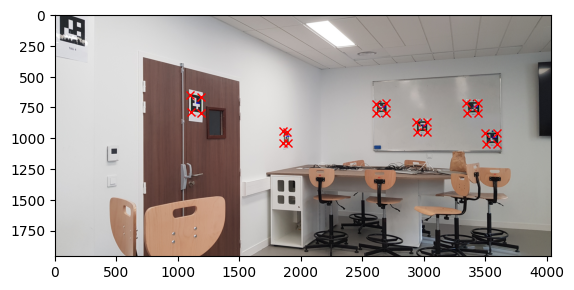

In [29]:
M_int = np.array([[f/s1,0,i1,0],[0,f/s2,i2,0],[0,0,1,0]],dtype=np.float32) # Matrice intrinsèque
M_ext = [[r11,r12,r13,o1c],[r21,r22,r23,o2c],[r31,r32,r33,o3c],[0,0,0,1]] # Matrice extrinsèque

plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

for i in range(len(ids)):
    for j in range(4):
        [u1,u2,u3] = np.dot(np.dot(M_int,M_ext),[dict_tags['coord_world_tags'][i][j][0],dict_tags['coord_world_tags'][i][j][1],dict_tags['coord_world_tags'][i][j][2],1])
        plt.plot(u1/u3,u2/u3,'rx')

mat_R = np.array([[r11,r12,r13],[r21,r22,r23],[r31,r32,r33]]) # Matrice de rotation
vec_T = np.array([o1c,o2c,o3c]) # Vecteur de translation
pos_cam = -np.dot(mat_R.T, vec_T)
print('Coordonnées de la caméra dans le repère monde:\n', pos_cam)


### 3 - Utilisation de la fonction d’openCV

Coordonnées de la caméra dans le repère monde:
 [[6751.68819064]
 [2379.5602833 ]
 [1210.33511799]]


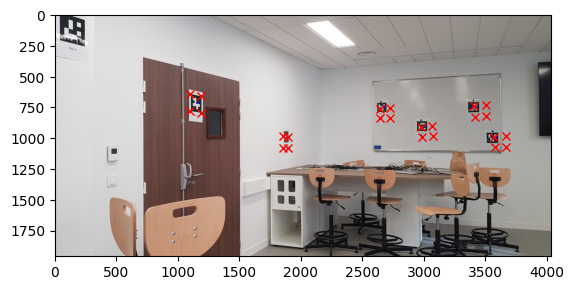

In [31]:
coord_world_tags = np.array(coord_world_tags,dtype=np.float32) # Coordonnées monde converties en float 32 pour la fonction opencv
M_int = np.array([[f/s1,0,i1],[0,f/s2,i2],[0,0,1]],dtype=np.float32) # Coefficients de la matrice intrinsèque convertis en float 32 pour la fonction opencv

ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(coord_world_tags,corners,(img.shape[1],img.shape[0]),M_int,None,flags=cv2.CALIB_USE_INTRINSIC_GUESS)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
for i in range(len(ids)):
    projected_points, _ = cv2.projectPoints(coord_world_tags[i], rvecs[0], tvecs[0], M_int, dist)
    for j in range(4):
        plt.plot(projected_points[j][0][0],projected_points[j][0][1],'rx')

mat_rot, _ = cv2.Rodrigues(rvecs[0])  # Convertir le vecteur de rotation en matrice de rotation
pos_cam = -np.dot(mat_rot.T, tvecs[0])
print('Coordonnées de la caméra dans le repère monde:\n', pos_cam)